## conda install

In [1]:
#!conda install -c conda-forge xgboost=3.0.2 lightgbm=4.6.0 missingno=0.5.2 -y

## 시작

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import os
from os.path import join

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor as lgb
from xgboost import XGBRegressor as xgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import VotingRegressor

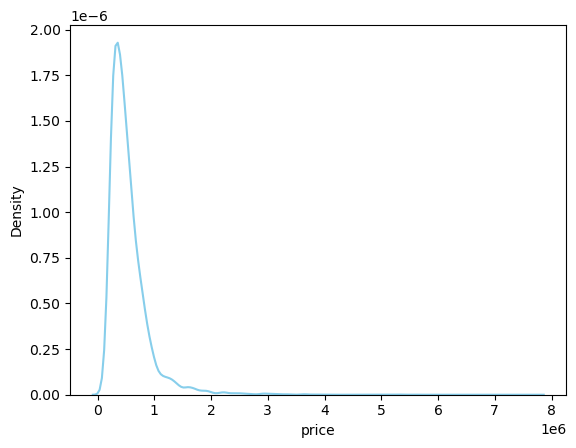

In [3]:
# 훈련 데이터와 테스트 데이터를 컴퓨터 메모리로 읽어옴
data_dir = './data'
train = pd.read_csv(join(data_dir, 'train.csv'))
test = pd.read_csv(join(data_dir, 'test.csv'))

# 날짜 데이터 정리
# '20141013T000000' 같은 복잡한 글자에서 앞의 6자리('201410')만 추출해 숫자로 바꿈
# 컴퓨터는 복잡한 문자열보다 단순한 숫자를 훨씬 더 잘 이해하여 패턴을 찾기 때문
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

# 정답지 분리
# 훈련 데이터에서 price 집값을 따로 떼어내어 y 변수에 저장
# 시험 공부할 때 문제집과 정답지를 분리하는 것과 같음
y = train['price']
del train['price'] # 훈련 데이터 문제집에서는 정답을 지움

# 불필요한 식별자 제거
# id는 몇 번째 데이터인지만 나타내는 고유 번호일 뿐, 집값의 비싸고 싼 패턴과는 아무런 상관 없음
# 모델이 id가 크면 집값이 비싸다는 오해로 과적합 하지 않도록 삭제
sub_id = test['id'] # 나중에 제출 파일 만들 때 쓰기 위해 시험지 id는 따로 저장
del train['id']
del test['id']

# 정답(집값)의 원래 분포 확인
sns.kdeplot(y, color='skyblue')
plt.show()
# 치우친 그래프 -> 모델이 학습하기 매우 힘든 형태, 로그 변환 필요

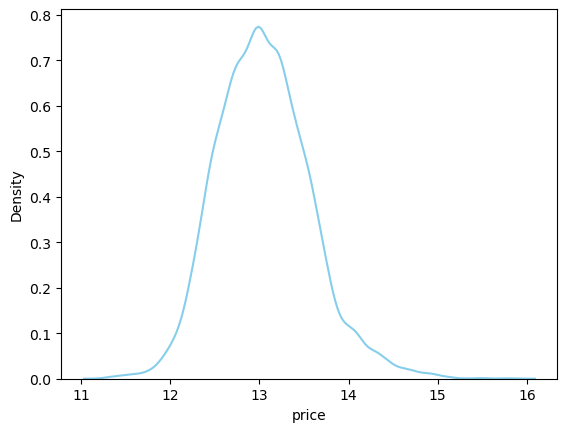

In [4]:
# 집의 나이, 총 방의 개수 등 파생 피처 생성
for df in [train, test]:
    # 총 방의 개수 = 침실 수 + 화장실 수 (집의 전체적인 규모를 나타냄)
    df['total_rooms'] = df['bedrooms'] + df['bathrooms']

    # 집의 나이 = 데이터 수집 연도(2015) - 건축 연도 (오래된 집일수록 가격이 떨어지는 경향 반영)
    df['age'] = 2015 - df['yr_built']

    # 재건축 여부 = 재건축 연도가 0보다 크면 1(재건축 됨), 0이면 0(안 됨)으로 처리
    df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
    
    # 마당 면적 sqft_lot 대비 실내 총 면적 sqft_living 비율(마당에 비해 집이 얼마나 꽉 차게 지어졌는가)
    # 0으로 나누는 치명적인 에러를 막기 위해 분모에 1을 더해주는 방어벽 + 1
    df['living_lot_ratio'] = df['sqft_living'] / (df['sqft_lot'] + 1)
    
    # 총 방 개수 대비 실내 면적 (방 하나당 평균 크기가 얼마나 널찍널찍한가)
    df['room_size_ratio'] = df['sqft_living'] / (df['total_rooms'] + 1)

    # 인근 이웃 15가구 평균 크기 대비 내 집의 크기 비율
    df['neighbor_size_ratio'] = df['sqft_living'] / (df['sqft_living15'] + 1)

# 입력 데이터 로그 변환
# 집의 평수나 마당 크기도 극소수의 엄청나게 큰 저택들 때문에 데이터가 한쪽으로 쏠려있음
# 분포가 한쪽으로 쏠려 있는 면적 피처들 로그 변환
# 이를 log1p() 함수를 이용해 예쁜 종 모양 정규 분포로 펴줌
skew_columns = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']
for c in skew_columns:
    train[c] = np.log1p(train[c])
    test[c] = np.log1p(test[c])

# 정답지 로그 변환
# 치우쳐 있던 집값 y의 분포도 로그 변환으로 펴줌
# 이 작업을 해두어야 머신러닝 모델들이 오차를 계산할 때 대저택 가격에 휘둘리지 않고 안정적으로 학습
y = np.log1p(y)

# 로그 변환 후의 집값 분포 확인
sns.kdeplot(y, color='skyblue')
plt.show()

In [9]:
def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5):
    """
    1. GridSearchCV 모델로 `model`을 초기화합니다.
    2. 모델을 fitting 합니다.
    3. params, score에 각 조합에 대한 결과를 저장합니다.
    4. 데이터 프레임을 생성하고, RMSLE 값을 추가한 후 점수가 높은 순서로 정렬한 `results`를 반환합니다.
    """
    # 초기화 (scoring을 neg_mean_squared_error로 설정해 오차 계산 준비)
    grid_model = GridSearchCV(model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=verbose, n_jobs=n_jobs)
    
    # 모델 학습
    grid_model.fit(train, y)

    # 결과값들 추출
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']

    # DataFrame 표로 만들어 정렬 후 반환
    results = pd.DataFrame(params)
    results['score'] = score
    results['RMSLE'] = np.sqrt(-1 * results['score']) # 음수 오차를 양수 루트 오차(RMSLE)로 변환
    results = results.sort_values(by='RMSLE') # 오차가 가장 적은(점수가 좋은) 순서로 정렬
    
    return results


def save_submission(model, train, y, test, model_name, rmsle=None):
    """
    1. 모델을 train, y로 학습시킵니다.
    2. test 데이터에 대해 예측합니다.
    3. 예측값에 expm1을 취하여 원래 스케일로 되돌립니다.
    4. 예측값을 submission 데이터프레임에 넣고 저장합니다.
    """
    # 모델 학습
    model.fit(train, y)
    
    # 시험지 test 데이터의 집값 예측
    prediction = model.predict(test)
    
    # 로그 스케일로 예측된 집값을 원래의 단위 가격으로 되돌려놓기 (expm1)
    # y에 log1p를 해줬기 때문에, 되돌릴 때도 expm1을 써야 원래 단위로 복원
    prediction = np.expm1(prediction)
    
    # 정답 양식지 파일(sample_submission.csv)을 열어서 예측값으로 덮어씀
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['price'] = prediction

    submission_csv_path = '{}/submission_{}_RMSLE_{}.csv'.format(data_dir, model_name, rmsle)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [7]:
# 하이퍼파라미터 미세 조정 및 3중 앙상블 투표
# random_state는 모델초기화나 데이터셋 구성에 사용되는 랜덤 시드값입니다.
#random_state=None    # 이게 초기값입니다. 아무것도 지정하지 않고 None을 넘겨주면 모델 내부에서 임의로 선택합니다.
random_state = 2020

# 기존에 검증된 최상의 효율을 내는 단일 모델 파라미터 세팅
# learning_rate를 0.03 낮춰서 조금씩 오차를 수정하며 학습
# n_estimators를 1500으로 높여 오랜 시간 정밀하게 공부하도록 과적합 방지

# best_lgbm = lgb(n_estimators=1500, max_depth=10, learning_rate=0.03, num_leaves=63, random_state=random_state)
# best_xgb = xgb(n_estimators=1500, max_depth=6, learning_rate=0.03, random_state=random_state)
# best_gb = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.05, random_state=random_state)

# subsample, colsample_bytree 옵션을 추가해 무작위성을 주어 과적합 방지
best_lgbm = lgb(n_estimators=1500, max_depth=10, learning_rate=0.03, num_leaves=63, subsample=0.8, colsample_bytree=0.8, random_state=random_state)
best_xgb = xgb(n_estimators=1500, max_depth=6, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, random_state=random_state)
best_gb = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.05, random_state=random_state)
# subsample=0.8: 데이터의 80%만 무작위로 쓰기
# colsample_bytree=0.8: 피처의 80%만 무작위로 쓰기

# 사이킷런 앙상블 공식 기능 VotingRegressor
# 세 모델을 한 팀으로 묶고, 집값 예측을 잘하는 lgbm과 xgb에 40%씩, gb에 20%의 신뢰도(가중치) 부여
# 셋이서 투표를 하여 평균값을 내기 때문에 단일 모델 혼자 예측해서 칠 수 있는 대형 사고(과적합) 차단
voting_model = VotingRegressor(estimators=[('lgbm', best_lgbm), ('xgb', best_xgb), ('gb', best_gb)],
    # weights=[0.4, 0.4, 0.2]
    weights=[0.45, 0.45, 0.1])

# 모델 이름 동적 생성
# voting_model 내부에 들어있는 이름들을 컴프리헨션 문법으로 꺼내어 'voting_lgbm_xgb_gb' 문자열을 자동 생성
model_names = [name for name, _ in voting_model.estimators]
auto_model_name = f"voting_{'_'.join(model_names)}"

# 앙상블 모델의 진짜 점수 미리 계산해보기 (교차 검증)
# 시험지 test를 열어보기 전, 훈련 데이터 train을 5조각으로 쪼개서 자체 모의고사 5번(cv=5).
# 모델이 시험에서 대략 몇 점을 맞을지 RMSLE 오차 추출
print("앙상블 모델의 실제 RMSLE 점수를 계산 중입니다... (약 1~2분 소요)")
cv_scores = cross_val_score(voting_model, train, y, scoring='neg_mean_squared_error', cv=5, n_jobs=5)
auto_rmsle = np.sqrt(-1 * np.mean(cv_scores)) # 5번의 시험 점수 평균을 내어 진짜 실력을 가늠

# 수동 지정 없이, 자동으로 계산된 변수들만 넣어서 함수 호출
save_submission(model=voting_model, train=train, y=y, test=test, model_name=auto_model_name, rmsle=f'{auto_rmsle:.6f}')
# 소수점 6자리까지 자동으로 문자열 변환되어 들어감

앙상블 모델의 실제 RMSLE 점수를 계산 중입니다... (약 1~2분 소요)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 25
[LightGBM] [Info] Start training from score 13.052839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

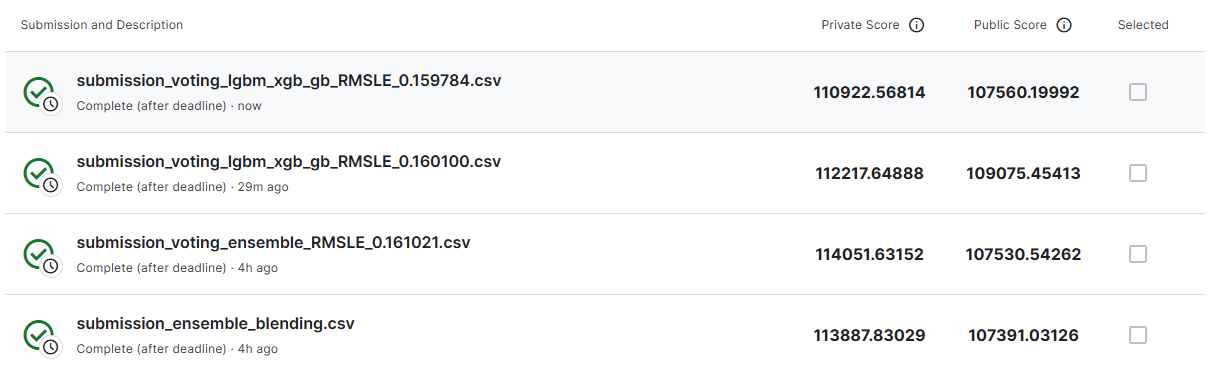

#### 회고
> 당장 흐름을 읽고 뭐가 필요한지 생각하고 찾는 것도 어려운 상태이기 때문에 혼자서는 해결하기 어렵다고 판단해서 ai로 공부하면서 진행했고, 주석이 과도하게 많아졌지만 이해하는게 먼저라서 다시 보려면 지울 수가 없다. 파생 피처와 앙상블은 특히 더 공부해야 할 것 같다.  

  
> 대략적인 수정 순서  
> 1. skew_columns -> log1p() 로그 함수로 펴주기  
> 2. 파생 피처  
> 4. 앙상블, VotingRegressor, 하이퍼 파라미터  
> 5. 앙상블 subsample, colsample_bytree 옵션 추가  
> 6. VotingRegressor 가중치 수정  
> 7. 파생 피처 neighbor_size_ratio 추가  